### 09-01-04. 군집 알고리즘

1. **K-평균 군집(K-Means Clustering)**
    - 데이터를 k개의 클러스터로 나누는 가장 널리 사용되는 군집 알고리즘이다.
    - **알고리즘 작동 방식**
        1. 클러스터 중심(centroid)을 초기화한다.
        2. 각 데이터 포인트를 가장 가까운 클러스터 중심에 할당한다.
        3. 클러스터 중심을 재계산한다.
        4. 중심이 수렴할 때까지 반복한다.
    - **장점:** 간단하고 빠르므로 대규모 데이터셋에 적합하다.
        
        **단점:** K값을 미리 설정해야 하고, 데이터 분포가 구형(Gaussian)에 가까워야 잘 작동한다.

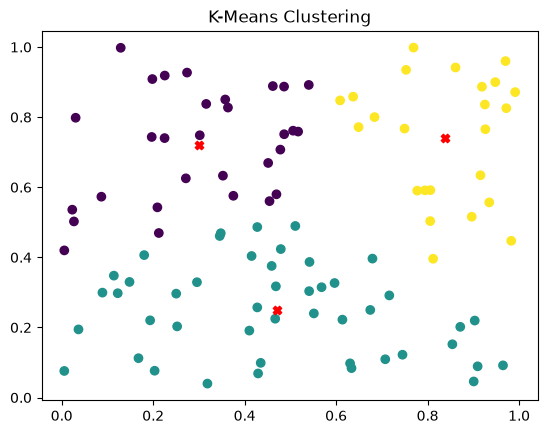

In [2]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

# 데이터 생성
X = np.random.rand(100, 2)

# K-평균 군집 모델 학습
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# 예측 및 시각화
labels = kmeans.predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], color='red', marker='X')
plt.title("K-Means Clustering")
plt.show()

### 09-02-05. 가우시안 혼합의 장단점

- **장점**
    - 클러스터 간 경계를 확률적으로 표현하여 더 유연하다.
    - 데이터가 가우시안 분포를 따른다면 높은 성능을 보인다.
- **단점**
    - 가우시안 분포 가정이 부적절한 경우 성능이 저하된다.
    - EM 알고리즘은 초기값에 민감하며, 지역 최적점에 빠질 수 있다.

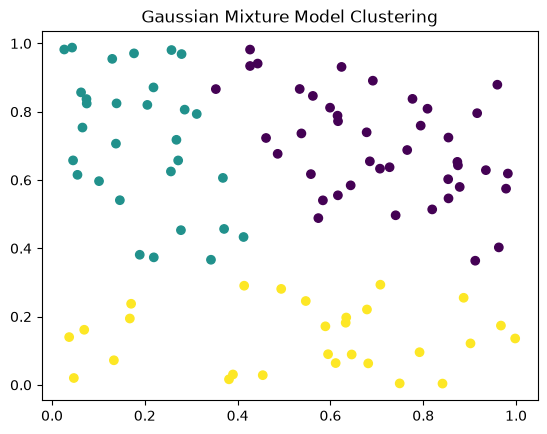

In [30]:
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt

# 데이터 생성
X = np.random.rand(100, 2)

# GMM 모델 학습
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X)

# 예측 및 시각화
labels = gmm.predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title("Gaussian Mixture Model Clustering")
plt.show()

## 09-03. 실루엣 분석(Silhouette Analysis)

### 09-03-01. 실루엣 계수(Silhouette Coefficient)

- **실루엣 계수**는 데이터 포인트가 얼마나 잘 군집화되었는지 평가하는 지표다. 실루엣 계수는 다음과 같은 수식으로 정의된다.
    
    $$
    s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
    $$
    
    - $a(i)$: $i$번째 데이터 포인트가 속한 군집 내의 다른 포인트들과의 평균 거리
    - $b(i)$: $i$번째 데이터 포인트와 가장 가까운 다른 군집의 포인트들과의 평균 거리

In [51]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import pandas as pd

# 예시 데이터 생성
from sklearn.datasets import make_blobs
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)

# K-평균 군집화 모델 학습
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)

# 실루엣 계수 계산
silhouette_avg = silhouette_score(X, kmeans.labels_)
print(f'Silhouette Score: {silhouette_avg:.2f}')

Silhouette Score: 0.88


## 9-04. DBSCAN 군집화

### 09-04-01. DBSCAN 군집화 수식

- **DBSCAN(Density-Based Spatial Clustering of Applications with Noise)**는 밀도 기반 군집화 알고리즘이다. 군집은 데이터 포인트 주변의 밀집도를 기준으로 형성된다.
- 핵심 파라미터는 **$\epsilon$** (거리 임계값)과 **minPts**(최소 이웃 데이터 수)이다.
    - 핵심 포인트(Core Point): $\epsilon$ 거리 내에 최소 **minPts** 이상의 이웃이 있는 데이터
    - 경계 포인트(Border Point): 핵심 포인트 주변에 있지만, **minPts**에는 미치지 못하는 데이터
    - 노이즈 포인트(Noise Point): 어느 군집에도 속하지 않는 데이터

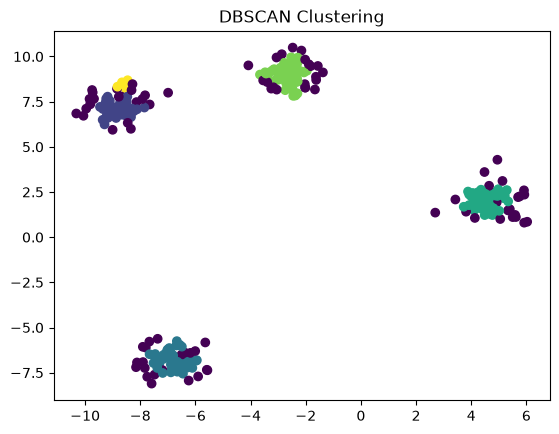

In [59]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# 예시 데이터 생성
from sklearn.datasets import make_blobs
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)

# DBSCAN 군집화 모델 학습
dbscan = DBSCAN(eps=0.3, min_samples=5)
y_dbscan = dbscan.fit_predict(X)

# 군집 결과 시각화
plt.scatter(X[:, 0], X[:, 1], c=y_dbscan, cmap='viridis')
plt.title('DBSCAN Clustering')
plt.show()